In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Upload dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Read dataset based on file extension
if file_name.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(file_name)
else:
    try:
        df = pd.read_csv(file_name, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_name, encoding='latin1')

df.columns = df.columns.str.strip()

# Target encoding for Attrition
df['Attrition_Numeric'] = df['Attrition'].apply(lambda x: 1 if str(x).strip().lower() in ['yes', '1', 'true'] else 0)

print("HR Dataset Loaded Successfully!")
print(f"Total Employees: {len(df):,} | Attributes: {len(df.columns)}")

Saving HR_sets.csv to HR_sets.csv
HR Dataset Loaded Successfully!
Total Employees: 1,480 | Attributes: 39


/tmp/ipykernel_4448/2615404485.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_4448/2615404485.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([f'{int(x*100)}%' for x in axes[0].get_yticks()])
/tmp/ipykernel_4448/2615404485.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_4448/2615404485.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(x*100)}%' for x in axes[1].get_yticks()])


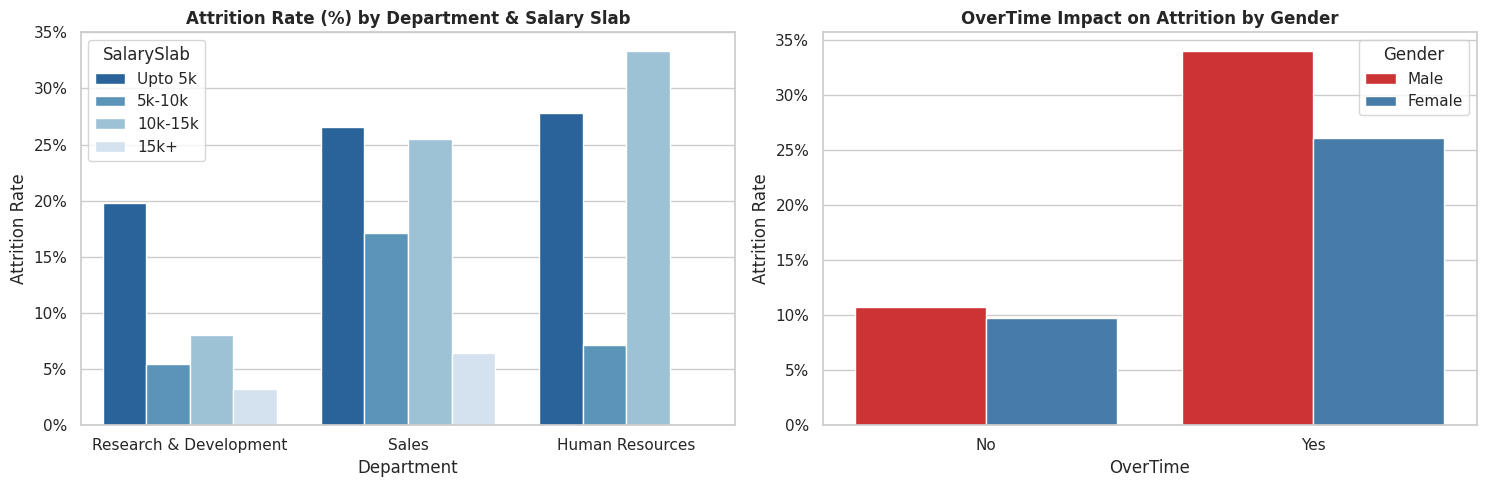

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Attrition Rate (%) by Department and SalarySlab
sns.barplot(
    ax=axes[0],
    data=df,
    x='Department',
    y='Attrition_Numeric',
    hue='SalarySlab',
    palette='Blues_r',
    ci=None
)
axes[0].set_title('Attrition Rate (%) by Department & Salary Slab', fontweight='bold')
axes[0].set_ylabel('Attrition Rate')
axes[0].set_yticklabels([f'{int(x*100)}%' for x in axes[0].get_yticks()])

# 2. Overtime Impact on Attrition by Gender
sns.barplot(
    ax=axes[1],
    data=df,
    x='OverTime',
    y='Attrition_Numeric',
    hue='Gender',
    palette='Set1',
    ci=None
)
axes[1].set_title('OverTime Impact on Attrition by Gender', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')
axes[1].set_yticklabels([f'{int(x*100)}%' for x in axes[1].get_yticks()])

plt.tight_layout()
plt.show()

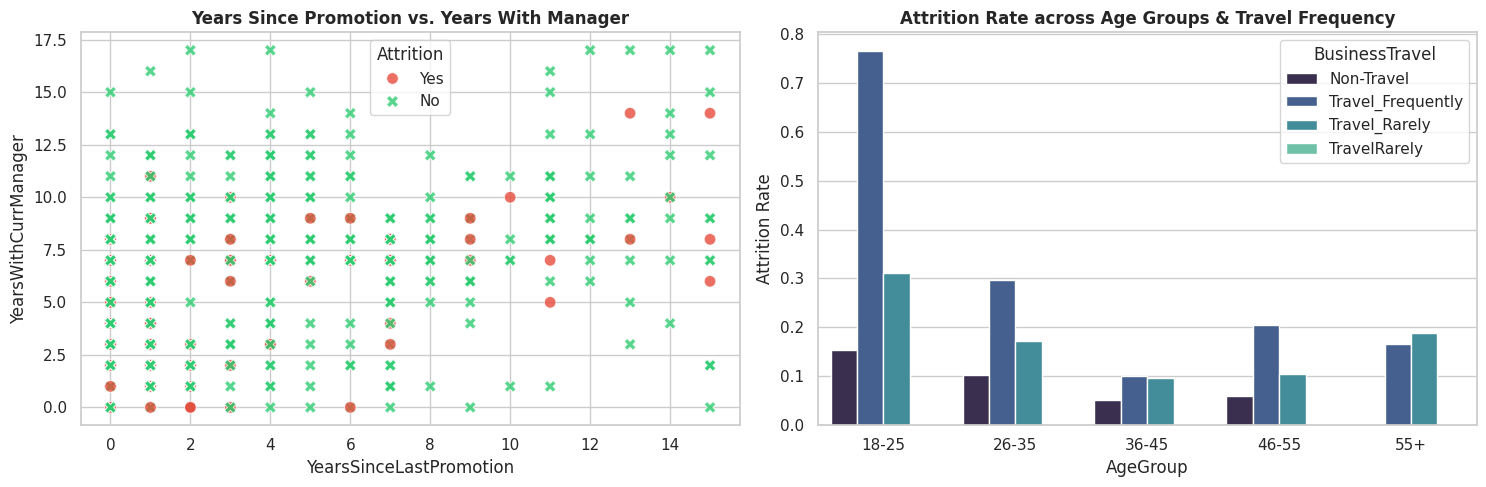

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Promotion Stagnation vs Years With Current Manager
sns.scatterplot(
    ax=axes[0],
    data=df,
    x='YearsSinceLastPromotion',
    y='YearsWithCurrManager',
    hue='Attrition',
    style='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
    alpha=0.8,
    s=70
)
axes[0].set_title('Years Since Promotion vs. Years With Manager', fontweight='bold')

# 2. Attrition Rate across Age Groups & Business Travel Frequency
age_travel = df.groupby(['AgeGroup', 'BusinessTravel'])['Attrition_Numeric'].mean().reset_index()

sns.barplot(
    ax=axes[1],
    data=age_travel,
    x='AgeGroup',
    y='Attrition_Numeric',
    hue='BusinessTravel',
    palette='mako'
)
axes[1].set_title('Attrition Rate across Age Groups & Travel Frequency', fontweight='bold')
axes[1].set_ylabel('Attrition Rate')

plt.tight_layout()
plt.show()

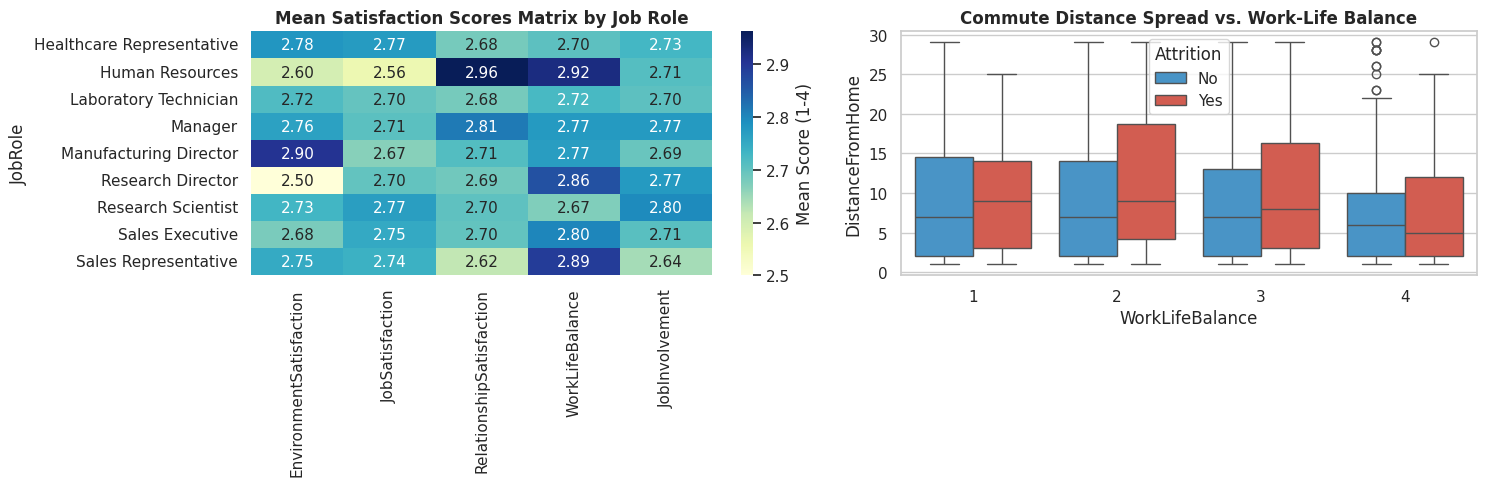

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Multi-Satisfaction Risk Matrix Heatmap
sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
sat_matrix = df.groupby('JobRole')[sat_cols].mean()

sns.heatmap(
    ax=axes[0],
    data=sat_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Mean Score (1-4)'}
)
axes[0].set_title('Mean Satisfaction Scores Matrix by Job Role', fontweight='bold')

# 2. Distance From Home vs Work-Life Balance Attrition
sns.boxplot(
    ax=axes[1],
    data=df,
    x='WorkLifeBalance',
    y='DistanceFromHome',
    hue='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#3498db'}
)
axes[1].set_title('Commute Distance Spread vs. Work-Life Balance', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4448/117503454.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='rocket')


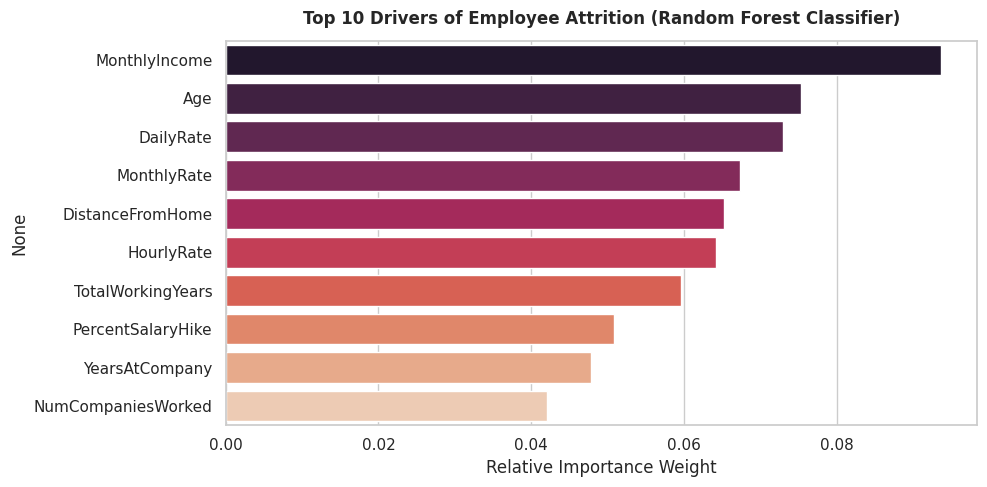

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Select numeric features for model training
feature_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'RelationshipSatisfaction',
    'WorkLifeBalance', 'StockOptionLevel'
]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['Attrition_Numeric']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Top 10 Drivers of Employee Attrition (Random Forest Classifier)', fontweight='bold', pad=12)
plt.xlabel('Relative Importance Weight')

plt.tight_layout()
plt.show()

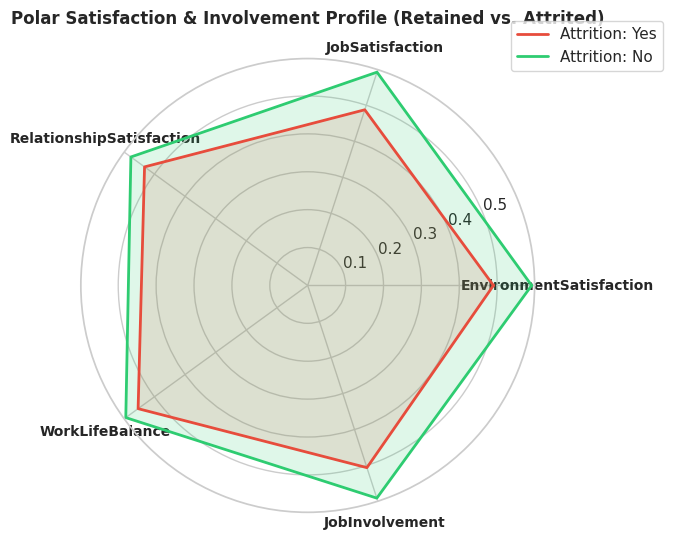

In [ ]:
import numpy as np

# Select key satisfaction and involvement metrics for radar comparison
radar_metrics = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

# Group mean ratings by Attrition status
radar_df = df.groupby('Attrition')[radar_metrics].mean()

# Normalize values between 0 and 1 for radar plotting
radar_norm = (radar_df - 1) / 3  # Ratings are on a 1-4 scale

# Set up radar angles
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = {'Yes': '#e74c3c', 'No': '#2ecc71'}

for attr_status in ['Yes', 'No']:
    values = radar_norm.loc[attr_status].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Attrition: {attr_status}', linewidth=2, color=colors[attr_status])
    ax.fill(angles, values, alpha=0.15, color=colors[attr_status])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10, fontweight='bold')
plt.title('Polar Satisfaction & Involvement Profile (Retained vs. Attrited)', fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Map multi-categorical flow from Department -> Job Role -> Salary Slab -> Attrition
fig = px.parallel_categories(
    df,
    dimensions=['Department', 'JobRole', 'SalarySlab', 'Attrition'],
    color='Attrition_Numeric',
    color_continuous_scale=px.colors.sequential.Reds,
    title='<b>Organizational Career Flow Pipeline (Department ➔ Role ➔ Salary Slab ➔ Attrition)</b>'
)

fig.update_layout(margin=dict(t=50, l=20, r=20, b=20), width=900, height=500)
fig.show()

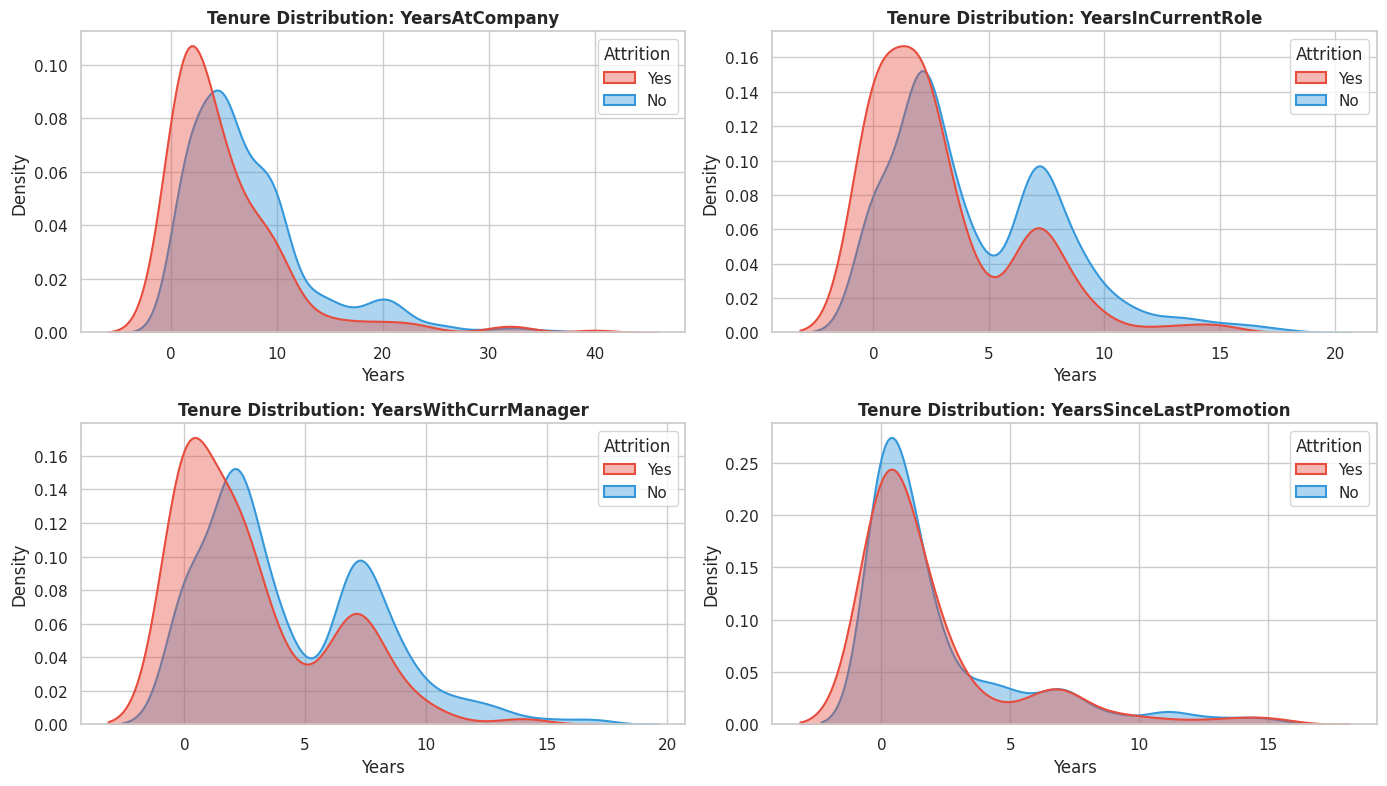

In [ ]:
tenure_vars = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, var in enumerate(tenure_vars):
    sns.kdeplot(
        ax=axes[idx],
        data=df,
        x=var,
        hue='Attrition',
        common_norm=False,
        fill=True,
        alpha=0.4,
        palette={'Yes': '#e74c3c', 'No': '#3498db'},
        linewidth=1.5
    )
    axes[idx].set_title(f'Tenure Distribution: {var}', fontweight='bold')
    axes[idx].set_xlabel('Years')
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_4448/3826863916.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




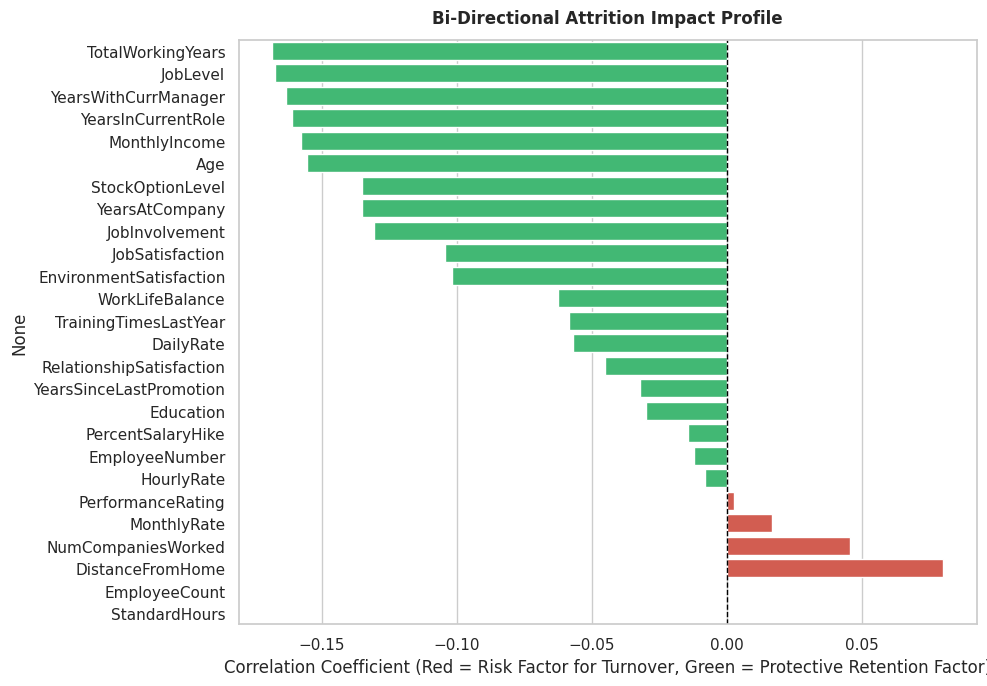

In [ ]:
# Compute directional correlation of numerical attributes against Attrition_Numeric
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Attrition_Numeric' in numeric_cols:
    numeric_cols.remove('Attrition_Numeric')

correlations = df[numeric_cols].apply(lambda col: col.corr(df['Attrition_Numeric'])).sort_values()

plt.figure(figsize=(10, 7))
bar_colors = ['#e74c3c' if val > 0 else '#2ecc71' for val in correlations.values]

sns.barplot(x=correlations.values, y=correlations.index, palette=bar_colors)
plt.title('Bi-Directional Attrition Impact Profile', fontweight='bold', pad=12)
plt.xlabel('Correlation Coefficient (Red = Risk Factor for Turnover, Green = Protective Retention Factor)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Render 3D interactive feature space: Monthly Income vs. Total Working Years vs. Distance From Home
fig = px.scatter_3d(
    df,
    x='MonthlyIncome',
    y='TotalWorkingYears',
    z='DistanceFromHome',
    color='Attrition',
    color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'},
    opacity=0.75,
    title='<b>3D HR Risk Space: Monthly Income vs. Total Working Years vs. Commute Distance</b>'
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40), width=850, height=600)
fig.show()

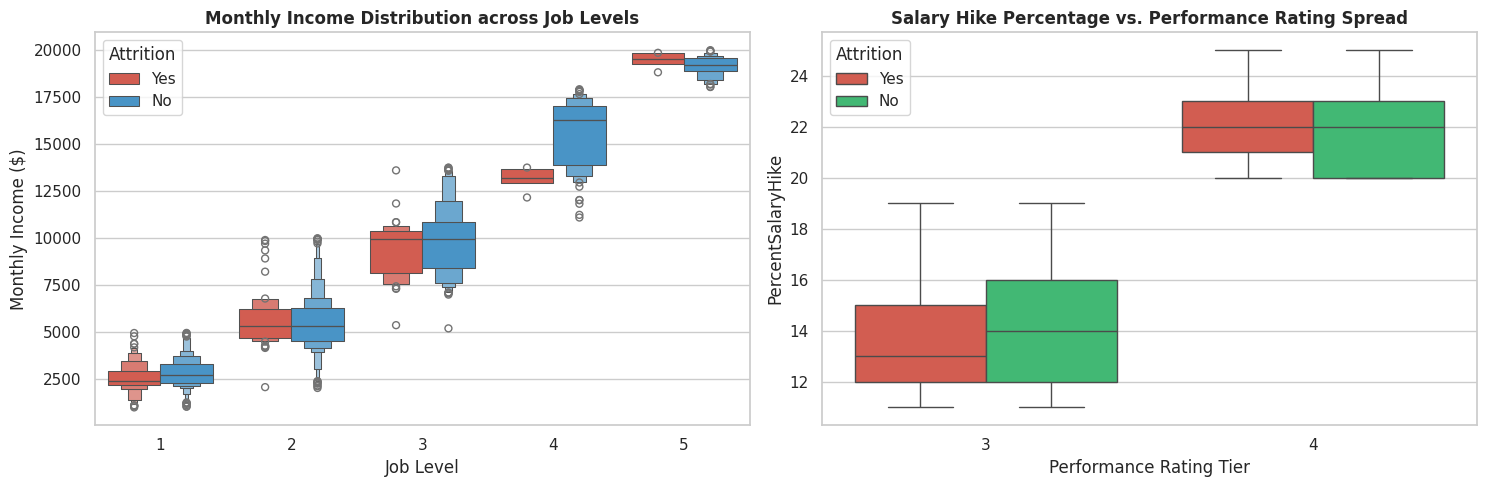

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Income Compression Across Job Levels & Attrition
sns.boxenplot(
    ax=axes[0],
    data=df,
    x='JobLevel',
    y='MonthlyIncome',
    hue='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#3498db'}
)
axes[0].set_title('Monthly Income Distribution across Job Levels', fontweight='bold')
axes[0].set_xlabel('Job Level')
axes[0].set_ylabel('Monthly Income ($)')

# 2. Percent Salary Hike vs. Performance Rating Impact
sns.boxplot(
    ax=axes[1],
    data=df,
    x='PerformanceRating',
    y='PercentSalaryHike',
    hue='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'}
)
axes[1].set_title('Salary Hike Percentage vs. Performance Rating Spread', fontweight='bold')
axes[1].set_xlabel('Performance Rating Tier')

plt.tight_layout()
plt.show()

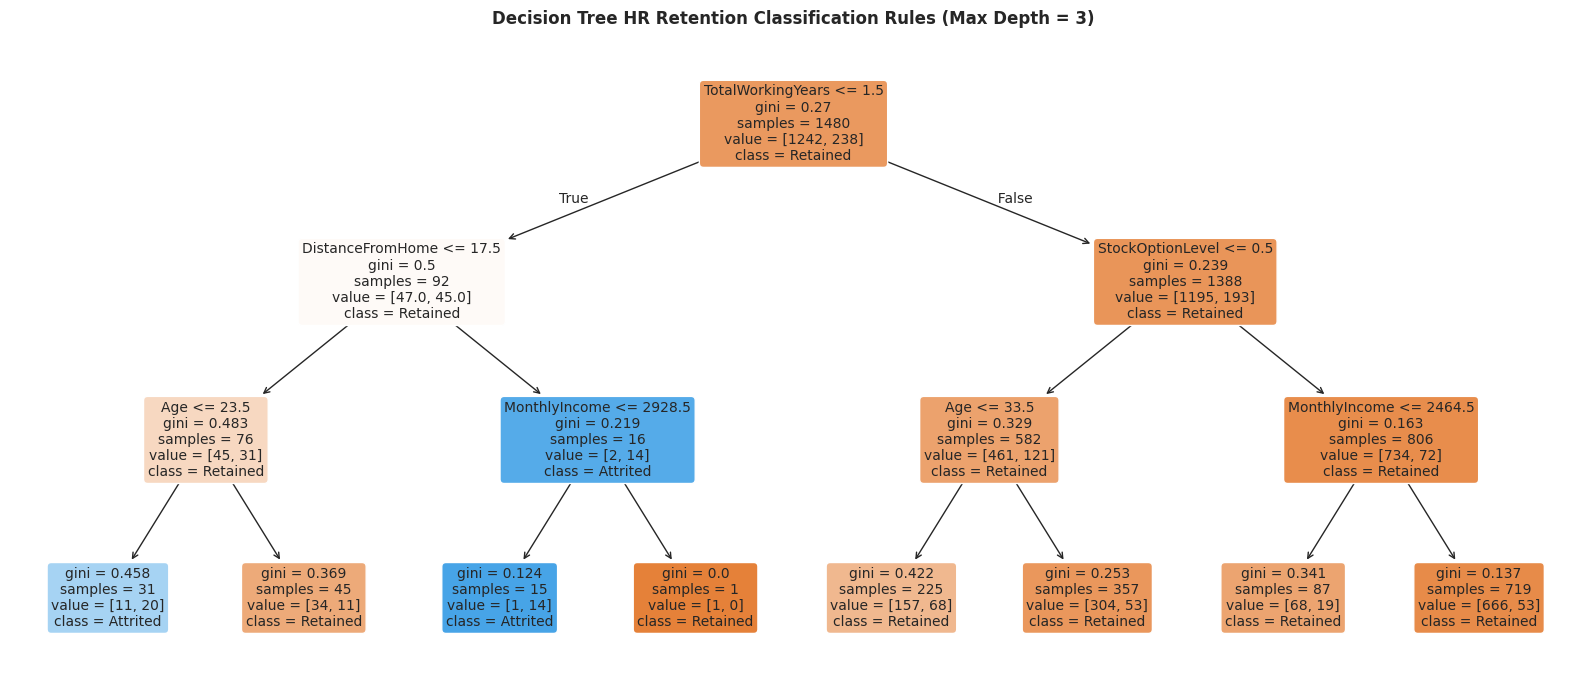

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train an interpretable depth-3 decision tree to extract explicit retention rules
dt_features = ['MonthlyIncome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome', 'StockOptionLevel']
X_dt = df[dt_features].fillna(df[dt_features].median())
y_dt = df['Attrition_Numeric']

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_dt, y_dt)

plt.figure(figsize=(16, 7))
plot_tree(
    dt,
    feature_names=dt_features,
    class_names=['Retained', 'Attrited'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree HR Retention Classification Rules (Max Depth = 3)', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

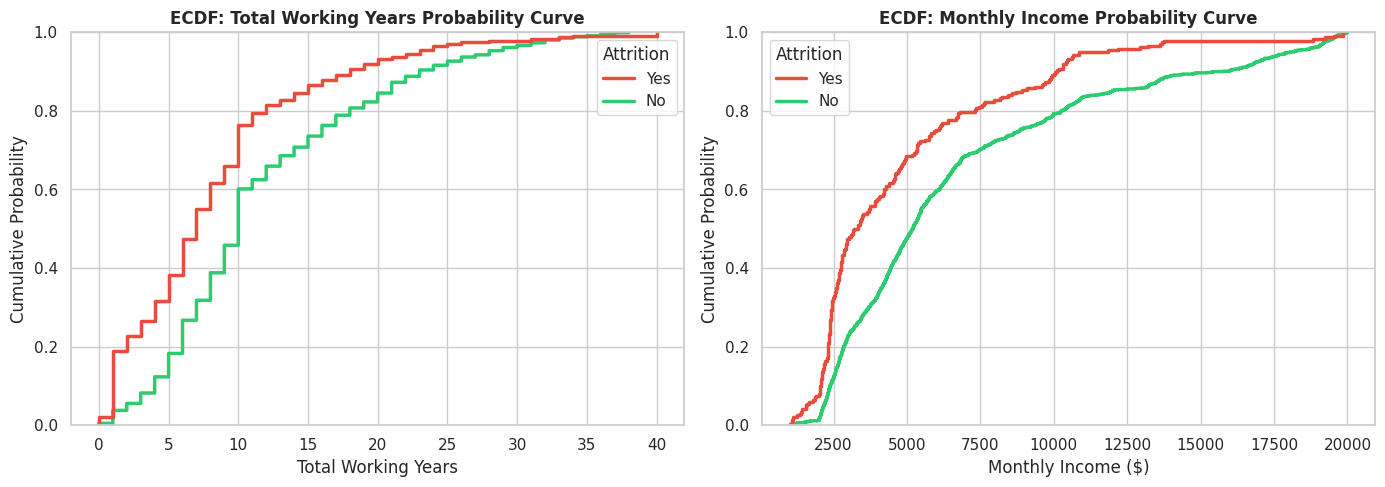

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cumulative Probability of Total Working Years
sns.ecdfplot(
    ax=axes[0],
    data=df,
    x='TotalWorkingYears',
    hue='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
    lw=2.5
)
axes[0].set_title('ECDF: Total Working Years Probability Curve', fontweight='bold')
axes[0].set_xlabel('Total Working Years')
axes[0].set_ylabel('Cumulative Probability')

# 2. Cumulative Probability of Monthly Income
sns.ecdfplot(
    ax=axes[1],
    data=df,
    x='MonthlyIncome',
    hue='Attrition',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
    lw=2.5
)
axes[1].set_title('ECDF: Monthly Income Probability Curve', fontweight='bold')
axes[1].set_xlabel('Monthly Income ($)')
axes[1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()